# TerraMind × xView2 — End-to-End Sanity Check

This notebook validates the full **TerraTorch + TerraMind xView2 building-damage segmentation** pipeline on a fixed subset of **10 image pairs** before committing to a full training run.

## What it does
1. Prepares a 10-pair subset from the raw xView2 tier-1 data (stacks pre+post → 6-band GeoTIFF, rasterizes JSON polygon labels → int16 mask)
2. Loads the subset through `GenericMultiModalDataModule` (single `S2L2A` modality)
3. Initialises `SemanticSegmentationTask` wrapping a `terramind_v1_base` backbone + `UNetDecoder` head
4. Runs **2 training iterations** via PyTorch Lightning Trainer (`fast_dev_run=2`)
5. Runs inference and visualises pre-event, post-event, ground truth, and predicted masks



## Switching to full training
Set `SANITY_CHECK = False` in the **Configuration** cell, then either run this notebook
or launch the CLI config directly:
```bash
python -m terratorch fit \
    --config examples/xview2/terramind_xview2_segmentation.yaml
```

---
**Class map:** 0 background · 1 no-damage · 2 minor-damage · 3 major-damage · 4 destroyed · −1 un-classified (ignored)

## Data Pipeline & Model Feeding — How It Works

### 1 · Raw xView2 Format
The xView2 tier-1 dataset ships as pairs of **3-band int16 WorldView-2 GeoTIFFs** (RGB-ish: coastal-blue, blue, green) plus **JSON polygon files** that annotate post-event building footprints with one of four damage states.

```
tier1/
├── images/
│   ├── <event>_<id>_pre_disaster.tif    ← 3-band int16, 1024×1024
│   └── <event>_<id>_post_disaster.tif
└── labels/
    └── <event>_<id>_post_disaster.json  ← GeoJSON polygon + damage properties
```

Damage property values in the JSON:
| JSON string | Integer class |
|---|---|
| `no-damage` | 1 |
| `minor-damage` | 2 |
| `major-damage` | 3 |
| `destroyed` | 4 |
| `un-classified` | −1 (ignored during loss) |
| (background) | 0 |

---

### 2 · Preprocessing (`prepare_xview2.py`)

Two transformations are applied once (idempotent, output cached to disk):

**Band stacking** — the pre-event and post-event 3-band GeoTIFFs are concatenated along the channel axis into a single **6-band int16 GeoTIFF**:

```
pre  [B0, B1, B2]  +  post [B3, B4, B5]
        └──────────────────────┘
              6-band image.tif
```

**Label rasterisation** — the JSON polygons are burned onto a blank `(H, W)` int16 array.  
A two-pass strategy handles overlapping polygons correctly:
1. First pass burns all damage polygons with their class IDs.
2. Second pass overwrites `un-classified` polygons last (value −1).  
Pixels outside any polygon remain class **0** (background).

---

### 3 · Datamodule & Normalisation

`GenericMultiModalDataModule` is used with **`concat_bands=False`** and a single modality named `S2L2A`.  
This is the critical configuration that makes TerraMind work correctly.

Under the hood each batch looks like:

```python
batch = {
    "image": {
        "S2L2A": Tensor(B, 6, H, W)   # float32, per-band normalised
    },
    "mask":  Tensor(B, H, W),          # int64, class 0-4 or -1
    "filename": [str, ...]
}
```

Per-band normalisation is applied by the datamodule (subtract mean, divide by std, band-wise).

---

### 4 · Why the modality key matters — TerraMind routing

`TerraMindViT` maintains a **registry of known modality tokenisers** (S2L2A, S1GRD, DEM, …).  
On each forward pass it loops over the keys of the input dict and routes each tensor to its modality-specific patch-embedding layer.  
**Any key that is not in the registry is silently discarded.**

Using `concat_bands=False` makes the datamodule produce the nested dict above, so `batch["image"]` is passed directly to the encoder as `{"S2L2A": tensor}` — the key matches and the tensor is tokenised correctly.

If `concat_bands=True` were used instead, `batch["image"]` would be a plain tensor (not a dict) and the model would raise `ValueError: No valid inputs provided`.

---

### 5 · Band Adaptation — 6 of 12 S2L2A Channels

Sentinel-2 L2A has 12 spectral bands; xView2 WorldView-2 has 3.  
After stacking, the 6-band file is declared as S2L2A bands `[0, 1, 2, 3, 4, 5]` (6 of 12).  
TerraMind's `select_modality_patch_embed_weights` function slices the pretrained 12-channel patch-projection weight matrix down to 6 channels, preserving the weights for those positions and discarding the rest.

---

### 6 · Model Architecture

```
Input: {"S2L2A": (B, 6, 224, 224)}
        │
        ▼
 TerraMindViT (ViT-Base, 12 layers)
   • S2L2A patch tokeniser  (adapted: 12→6 channels)
   • 12× Transformer blocks
        │
        ▼  SelectIndices([2, 5, 8, 11])  ← 4 intermediate feature maps
        ▼  ReshapeTokensToImage          ← (B, C, h, w) spatial maps
        ▼  LearnedInterpolateToPyramidal ← FPN-style multi-scale pyramid
        │
        ▼
 UNetDecoder  [512→256→128→64 channels]
        │
        ▼
 Segmentation head  →  (B, 5, H, W) logits
```

Loss: cross-entropy, `ignore_index=-1` (un-classified pixels excluded).

## 1 · Setup and Imports

In [11]:
import sys, pathlib, warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

import numpy as np
import torch
import albumentations as A
from albumentations.pytorch import ToTensorV2
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import rasterio
import lightning as L

# Make prepare_xview2.py importable (it lives in the same directory)
REPO_ROOT  = pathlib.Path("/dccstor/terratorch/users/aemam/testing-pr/terratorch.pr-1113-run")
SCRIPT_DIR = REPO_ROOT / "examples" / "xview2"
if str(SCRIPT_DIR) not in sys.path:
    sys.path.insert(0, str(SCRIPT_DIR))

from prepare_xview2 import write_stacked_image, rasterize_label, write_mask

print(f"PyTorch  : {torch.__version__}")
print(f"Lightning: {L.__version__}")
print(f"Device   : {'GPU (' + torch.cuda.get_device_name(0) + ')' if torch.cuda.is_available() else 'CPU'}")

PyTorch  : 2.9.1+cu128
Lightning: 2.6.0
Device   : CPU


## 2 · Configuration and Paths

Set `SANITY_CHECK = True` to use the 10-sample subset (fast, CPU-friendly).  
Set `SANITY_CHECK = False` to point to the full dataset and run real training.

In [12]:
# ── Toggle ──────────────────────────────────────────────────────────────────
SANITY_CHECK = True   # False → full training mode (see Section 8)

# ── Paths ────────────────────────────────────────────────────────────────────
# Raw xView2 tier-1 source (images + JSON labels)
RAW_SRC = pathlib.Path("/dccstor/geofm-datasets/datasets/xview2/geotiffs/tier1")

# Prepared TerraTorch dataset (created by prepare_xview2.py for full runs)
FULL_DST = pathlib.Path("/dccstor/geofm-datasets/datasets/xview2_terratorch")

# 10-sample working directory used in sanity-check mode
SANITY_DIR = pathlib.Path("/tmp/xview2_sanity")

# Active dataset root (switched by SANITY_CHECK flag)
DATASET_DIR = SANITY_DIR if SANITY_CHECK else FULL_DST

# ── Hyperparameters ──────────────────────────────────────────────────────────
CFG = dict(
    num_classes   = 5,
    batch_size    = 2,
    lr            = 6e-5,
    ignore_index  = -1,
    # fast_dev_run=N: Lightning runs exactly N train + N val batches then stops
    fast_dev_run  = 2 if SANITY_CHECK else False,
    max_epochs    = 1 if SANITY_CHECK else 100,
    precision     = "16-mixed" if torch.cuda.is_available() else "32",
    # Normalization stats — replace with output of: prepare_xview2.py --compute-stats
    means = [394.0, 428.0, 362.0, 380.0, 412.0, 348.0],
    stds  = [180.0, 175.0, 160.0, 185.0, 178.0, 164.0],
)

if SANITY_CHECK:
    print(f"Mode      : SANITY CHECK (10 samples, fast_dev_run={CFG['fast_dev_run']} batches)")
else:
    print("Mode      : FULL TRAINING")
print(f"Dataset   : {DATASET_DIR}")
print(f"Precision : {CFG['precision']}")

Mode      : SANITY CHECK (10 samples, fast_dev_run=2 batches)
Dataset   : /tmp/xview2_sanity
Precision : 32


## 3 · Sanity-Check Dataset Loading (10 Images)

Picks the first 10 complete pre/post/JSON triples (alphabetically sorted → deterministic),
stacks them into 6-band GeoTIFFs, and rasterizes the polygon labels into int16 masks.
This cell is idempotent: already-processed files are skipped.

In [13]:
if SANITY_CHECK:
    for sub in ("images", "masks", "splits"):
        (SANITY_DIR / sub).mkdir(parents=True, exist_ok=True)

    # Pick first 10 complete pairs (sorted → deterministic, seed-independent)
    stems: list[str] = []
    for pre in sorted((RAW_SRC / "images").glob("*_pre_disaster.tif")):
        stem = pre.stem.replace("_pre_disaster", "")
        post = RAW_SRC / "images" / f"{stem}_post_disaster.tif"
        lbl  = RAW_SRC / "labels" / f"{stem}_post_disaster.json"
        if post.exists() and lbl.exists():
            stems.append(stem)
        if len(stems) == 10:
            break

    print(f"Selected {len(stems)} pairs:")
    for s in stems:
        print(f"  {s}")

    # Process each pair (idempotent)
    for stem in stems:
        img_out  = SANITY_DIR / "images" / f"{stem}.tif"
        mask_out = SANITY_DIR / "masks"  / f"{stem}.tif"
        if img_out.exists() and mask_out.exists():
            continue
        h, w = write_stacked_image(
            RAW_SRC / "images" / f"{stem}_pre_disaster.tif",
            RAW_SRC / "images" / f"{stem}_post_disaster.tif",
            img_out,
        )
        mask = rasterize_label(RAW_SRC / "labels" / f"{stem}_post_disaster.json", h, w)
        write_mask(mask, mask_out, RAW_SRC / "images" / f"{stem}_post_disaster.tif")

    # Write split files: 8 train, 1 val, 1 test
    (SANITY_DIR / "splits" / "train.txt").write_text("\n".join(stems[:8]) + "\n")
    (SANITY_DIR / "splits" / "val.txt").write_text(stems[8] + "\n")
    (SANITY_DIR / "splits" / "test.txt").write_text(stems[9] + "\n")

    print("\nAll pairs ready.")
else:
    # For full training the dataset was already prepared by prepare_xview2.py
    stems = [p.stem for p in sorted((FULL_DST / "images").glob("*.tif"))]
    print(f"Full dataset: {len(stems)} prepared pairs found in {FULL_DST / 'images'}")

Selected 10 pairs:
  guatemala-volcano_00000000
  guatemala-volcano_00000001
  guatemala-volcano_00000002
  guatemala-volcano_00000006
  guatemala-volcano_00000007
  guatemala-volcano_00000008
  guatemala-volcano_00000010
  guatemala-volcano_00000013
  guatemala-volcano_00000015
  guatemala-volcano_00000016

All pairs ready.


In [14]:
from terratorch.datamodules.generic_multimodal_data_module import GenericMultiModalDataModule

dm = GenericMultiModalDataModule(
    task="segmentation",
    batch_size=CFG["batch_size"],
    num_workers=0,
    num_classes=CFG["num_classes"],
    modalities=["S2L2A"],
    # ── paths ──────────────────────────────────────────────────────────────
    train_data_root={"S2L2A": DATASET_DIR / "images"},
    train_label_data_root=DATASET_DIR / "masks",
    train_split=DATASET_DIR / "splits" / "train.txt",
    val_data_root={"S2L2A": DATASET_DIR / "images"},
    val_label_data_root=DATASET_DIR / "masks",
    val_split=DATASET_DIR / "splits" / "val.txt",
    # ── file discovery ─────────────────────────────────────────────────────
    image_grep={"S2L2A": "*.tif"},
    label_grep="*.tif",
    allow_substring_file_names=True,
    # ── band selection ─────────────────────────────────────────────────────
    dataset_bands={"S2L2A": list(range(6))},
    output_bands={"S2L2A": list(range(6))},
    # ── normalisation ──────────────────────────────────────────────────────
    means={"S2L2A": CFG["means"]},
    stds={"S2L2A": CFG["stds"]},
    no_data_replace=0.0,
    no_label_replace=CFG["ignore_index"],
    # ── misc ───────────────────────────────────────────────────────────────
    concat_bands=False,   # TerraMind expects {"S2L2A": tensor}, not a flat tensor
    drop_last=False,
    train_transform=A.Compose([A.RandomCrop(224, 224), ToTensorV2(transpose_mask=False)]),
    val_transform=A.Compose([A.CenterCrop(224, 224), ToTensorV2(transpose_mask=False)]),
)
dm.setup("fit")

# ── Inspect one batch ───────────────────────────────────────────────────────
train_loader = dm.train_dataloader()
batch = next(iter(train_loader))
img   = batch["image"]["S2L2A"]   # (B, 6, H, W)  float32, normalised
mask  = batch["mask"]              # (B, H, W)      int64

print(f"Train batches available : {len(train_loader)}")
print(f"image['S2L2A'] shape   : {img.shape}   dtype: {img.dtype}")
print(f"mask shape             : {mask.shape}   dtype: {mask.dtype}")
print(f"mask unique values     : {mask.unique().tolist()}  "
      f"(-1=ignored, 0=bg, 1-4=damage)")

import collections
flat = mask.view(-1).numpy()
counts = collections.Counter(flat[flat >= 0])
print(f"Class distribution (excl. -1): { {k: v for k, v in sorted(counts.items())} }")

2026-05-12 07:48:05,177 - INFO - Train dataset: 8
2026-05-12 07:48:05,178 - INFO - Val dataset: 1
2026-05-12 07:48:05,178 - INFO - Checking dataset stackability for train split


Train batches available : 4
image['S2L2A'] shape   : torch.Size([2, 6, 224, 224])   dtype: torch.float32
mask shape             : torch.Size([2, 224, 224])   dtype: torch.int64
mask unique values     : [0, 1]  (-1=ignored, 0=bg, 1-4=damage)
Class distribution (excl. -1): {np.int64(0): 98316, np.int64(1): 2036}


## 4 · TerraMind Model Initialisation

Builds a `terramind_v1_base` backbone with 6-of-12 S2L2A bands selected via
`select_modality_patch_embed_weights` (adapts the pretrained patch-projection layer from 12→6 channels).

> **Sanity check:** `backbone_pretrained=False` (random weights, no download).  
> For real training set `backbone_pretrained=True` to load the IBM pretrained checkpoint.

In [15]:
from terratorch.tasks import SemanticSegmentationTask

task = SemanticSegmentationTask(
    model_factory="EncoderDecoderFactory",
    model_args=dict(
        backbone="terramind_v1_base",
        backbone_pretrained=False,          # True for real training
        backbone_modalities=["S2L2A"],
        backbone_bands={"S2L2A": list(range(6))},   # 6-of-12 S2L2A bands
        necks=[
            {"name": "SelectIndices",         "indices": [2, 5, 8, 11]},
            {"name": "ReshapeTokensToImage",  "remove_cls_token": False},
            {"name": "LearnedInterpolateToPyramidal"},
        ],
        decoder="UNetDecoder",
        decoder_channels=[512, 256, 128, 64],
        head_dropout=0.1,
        num_classes=CFG["num_classes"],
    ),
    loss="ce",
    ignore_index=CFG["ignore_index"],
    lr=CFG["lr"],
    class_names=["background", "no-damage", "minor-damage", "major-damage", "destroyed"],
)

n_params  = sum(p.numel() for p in task.parameters()) / 1e6
n_trainable = sum(p.numel() for p in task.parameters() if p.requires_grad) / 1e6
print(f"Total parameters    : {n_params:.1f} M")
print(f"Trainable parameters: {n_trainable:.1f} M")

# Confirm output shape with a dummy forward pass
task.eval()
with torch.no_grad():
    dummy_out = task.model({"S2L2A": torch.zeros(1, 6, 224, 224)})
print(f"\nDummy forward output shape: {dummy_out.output.shape}")
assert dummy_out.output.shape == torch.Size([1, CFG["num_classes"], 224, 224]), \
    f"Unexpected output shape: {dummy_out.output.shape}"
print("Output shape matches expected (B, num_classes, H, W) ✓")

Total parameters    : 101.7 M
Trainable parameters: 101.7 M

Dummy forward output shape: torch.Size([1, 5, 224, 224])
Output shape matches expected (B, num_classes, H, W) ✓


## 5 · Short Training Loop (1–2 Iterations)

`fast_dev_run=2` tells PyTorch Lightning to run exactly **2 train batches + 2 val batches**
then stop — enough to confirm the forward pass, loss computation, backward pass, and metric
logging all work correctly end-to-end.

In [16]:
task.train()   # ensure training mode after the eval() in the model cell

trainer = L.Trainer(
    accelerator="auto",
    devices=1,
    fast_dev_run=CFG["fast_dev_run"],   # 2 train + 2 val batches in sanity mode
    max_epochs=CFG["max_epochs"],
    precision=CFG["precision"],
    enable_checkpointing=False,
    logger=False,
    enable_model_summary=False,
    enable_progress_bar=True,
)

print(f"Running trainer.fit  (fast_dev_run={CFG['fast_dev_run']}) …")
trainer.fit(task, datamodule=dm)
print("\nTraining completed ✓")

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
Running in `fast_dev_run` mode: will run the requested loop using 2 batch(es). Logging and checkpointing is suppressed.
2026-05-12 07:48:07,497 - INFO - Train dataset: 8
2026-05-12 07:48:07,497 - INFO - Val dataset: 1
2026-05-12 07:48:07,502 - INFO - Checking dataset stackability for train split


Running trainer.fit  (fast_dev_run=2) …


2026-05-12 07:48:08,116 - INFO - Checking dataset stackability for val split


Output()

`Trainer.fit` stopped: `max_steps=2` reached.



Training completed ✓


## 6 · Inference on Subset

Run a forward pass in eval mode on all samples loaded so far.
Assertions confirm that output shapes exactly match the input spatial dimensions.

In [17]:
task.eval()
device = next(task.parameters()).device

all_images = []   # (N, 6, 224, 224)  normalised
all_masks  = []   # (N, 224, 224)     int64
all_preds  = []   # (N, 224, 224)     int64
all_logits = []   # (N, 5, 224, 224)  float32

# Use val dataloader so we see the same samples as validation does
val_loader = dm.val_dataloader()

with torch.no_grad():
    for vbatch in val_loader:
        imgs  = vbatch["image"]["S2L2A"].to(device)
        masks = vbatch["mask"].to(device)
        out   = task.model({"S2L2A": imgs})

        logits = out.output                      # (B, 5, H, W)
        preds  = logits.argmax(dim=1)            # (B, H, W)

        all_images.append(imgs.cpu())
        all_masks.append(masks.cpu())
        all_preds.append(preds.cpu())
        all_logits.append(logits.cpu())

all_images = torch.cat(all_images)   # (N, 6, H, W)
all_masks  = torch.cat(all_masks)    # (N, H, W)
all_preds  = torch.cat(all_preds)    # (N, H, W)
all_logits = torch.cat(all_logits)   # (N, 5, H, W)

N, _, H, W = all_images.shape
print(f"Inference on {N} sample(s)")
print(f"  logits shape : {all_logits.shape}")
print(f"  preds  shape : {all_preds.shape}")
assert all_logits.shape == torch.Size([N, CFG["num_classes"], H, W])
assert all_preds.shape  == torch.Size([N, H, W])
print("Output shapes match expected (N, num_classes, H, W) ✓")
print(f"  Predicted class distribution: { {int(k): int(v) for k, v in zip(*all_preds.unique(return_counts=True))} }")

# Check loss is finite
loss_val = torch.nn.functional.cross_entropy(
    all_logits, all_masks.long(), ignore_index=CFG["ignore_index"]
).item()
assert not (loss_val != loss_val), "Loss is NaN!"
print(f"  Inference CE loss (random weights): {loss_val:.4f} (finite ✓)")

2026-05-12 07:48:16,401 - INFO - Checking dataset stackability for val split


Inference on 1 sample(s)
  logits shape : torch.Size([1, 5, 224, 224])
  preds  shape : torch.Size([1, 224, 224])
Output shapes match expected (N, num_classes, H, W) ✓
  Predicted class distribution: {0: 19, 1: 3330, 2: 46093, 4: 734}
  Inference CE loss (random weights): 16.7947 (finite ✓)


## 7 · Visualisation of Inputs, Labels and Predictions

Each row shows one sample:
| Pre-event (RGB) | Post-event (RGB) | Ground truth | Prediction |

**Colour map:** dark=background · green=no-damage · yellow=minor · orange=major · red=destroyed · grey=un-classified (ignored)

> With random (untrained) weights, predictions will be noisy — this is expected.
> After full training the predicted masks should approximate the ground truth.

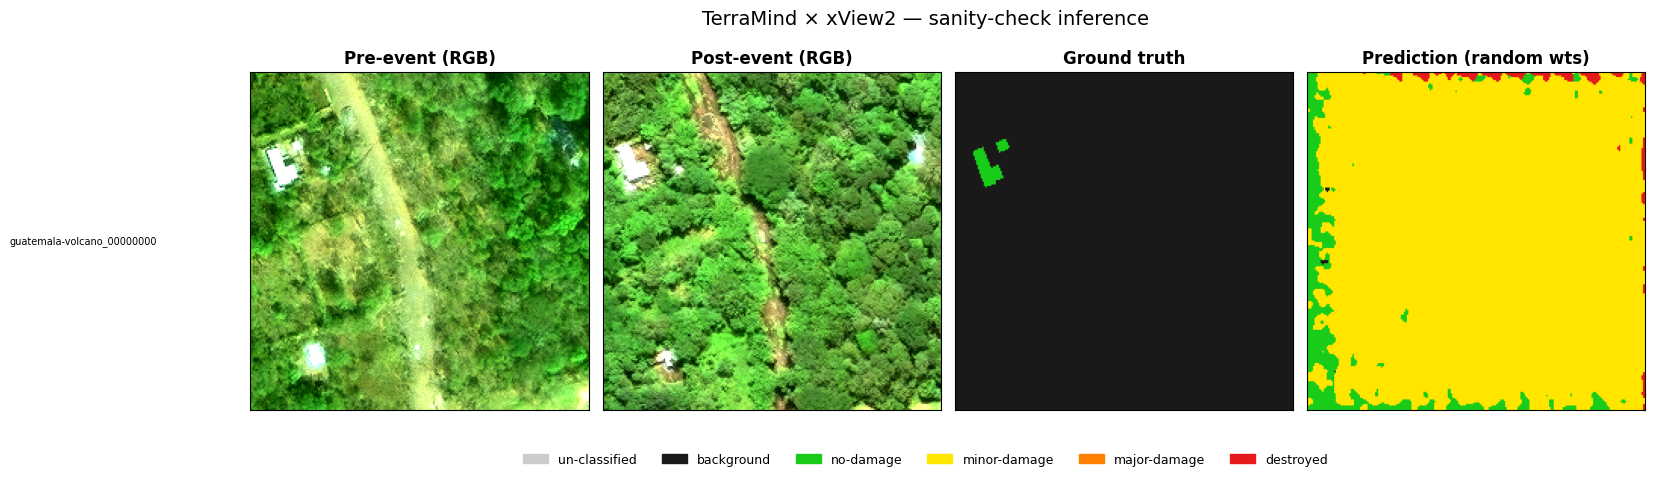

Figure saved → /tmp/xview2_sanity/sanity_check_vis.png


In [18]:
# ── Colour palette (consistent with prepare_xview2 class map) ───────────────
CLASS_COLORS = {
    -1: [0.80, 0.80, 0.80],   # un-classified → light grey
     0: [0.10, 0.10, 0.10],   # background    → near-black
     1: [0.10, 0.80, 0.10],   # no-damage     → green
     2: [1.00, 0.90, 0.00],   # minor-damage  → yellow
     3: [1.00, 0.50, 0.00],   # major-damage  → orange
     4: [0.90, 0.10, 0.10],   # destroyed     → red
}
CLASS_NAMES = {
    -1: "un-classified", 0: "background", 1: "no-damage",
     2: "minor-damage",  3: "major-damage", 4: "destroyed",
}

def colorize_mask(m: np.ndarray) -> np.ndarray:
    """Map an int mask (H, W) → float32 RGB (H, W, 3)."""
    rgb = np.zeros((*m.shape, 3), dtype=np.float32)
    for val, color in CLASS_COLORS.items():
        rgb[m == val] = color
    return rgb

def to_display_rgb(img_tensor: torch.Tensor, band_indices: list[int]) -> np.ndarray:
    """Denormalise and percentile-clip a (6, H, W) tensor for display as (H, W, 3)."""
    m = torch.tensor(CFG["means"], dtype=torch.float32).view(-1, 1, 1)
    s = torch.tensor(CFG["stds"],  dtype=torch.float32).view(-1, 1, 1)
    raw = (img_tensor * s + m)                            # denormalise
    rgb = raw[band_indices].permute(1, 2, 0).numpy()      # (H, W, 3)
    lo  = np.percentile(rgb[rgb > 0], 2,  axis=0) if (rgb > 0).any() else np.zeros(3)
    hi  = np.percentile(rgb[rgb > 0], 98, axis=0) if (rgb > 0).any() else np.ones(3)
    return np.clip((rgb - lo) / (hi - lo + 1e-6), 0, 1)

# ── Grid plot ────────────────────────────────────────────────────────────────
n_show = min(len(all_images), 4)   # cap at 4 rows for readability
fig, axes = plt.subplots(n_show, 4, figsize=(18, 4.5 * n_show),
                         gridspec_kw={"hspace": 0.05, "wspace": 0.04})
if n_show == 1:
    axes = axes[np.newaxis, :]

col_titles = ["Pre-event (RGB)", "Post-event (RGB)", "Ground truth", "Prediction (random wts)"]
for col, title in enumerate(col_titles):
    axes[0, col].set_title(title, fontsize=12, fontweight="bold")

for i in range(n_show):
    img = all_images[i]                          # (6, H, W) normalised
    gt  = all_masks[i].numpy()                   # (H, W)
    pr  = all_preds[i].numpy()                   # (H, W)

    axes[i, 0].imshow(to_display_rgb(img, [0, 1, 2]))   # pre  R G B
    axes[i, 1].imshow(to_display_rgb(img, [3, 4, 5]))   # post R G B
    axes[i, 2].imshow(colorize_mask(gt))
    axes[i, 3].imshow(colorize_mask(pr))
    axes[i, 0].set_ylabel(stems[i] if i < len(stems) else str(i),
                          fontsize=7, rotation=0, labelpad=120, va="center")
    for ax in axes[i]:
        ax.set_xticks([]); ax.set_yticks([])

legend_patches = [
    mpatches.Patch(color=c, label=CLASS_NAMES[k])
    for k, c in CLASS_COLORS.items()
]
fig.legend(handles=legend_patches, loc="lower center", ncol=7,
           fontsize=9, bbox_to_anchor=(0.5, -0.03), frameon=False)
plt.suptitle("TerraMind × xView2 — sanity-check inference", fontsize=14, y=1.01)
plt.savefig(SANITY_DIR / "sanity_check_vis.png", dpi=120, bbox_inches="tight")
plt.show()
print(f"Figure saved → {SANITY_DIR / 'sanity_check_vis.png'}")

## 8 · Switching to Full Training

Everything needed is in place. To move from this sanity check to a full training run:

### Option A — Via this notebook
1. Set `SANITY_CHECK = False` in the **Configuration** cell (Section 2)
2. Set `backbone_pretrained=True` in the **Model** cell (Section 4) to load pretrained weights
3. Re-run all cells — the DataModule will point to the full 2799-pair dataset
4. The Trainer will run for `max_epochs=100` with `fast_dev_run=False`

### Option B — Via the CLI config (recommended for long runs)
```bash
# Step 1: Prepare the full dataset (~15 min, idempotent)
python examples/xview2/prepare_xview2.py \
    --src /dccstor/geofm-datasets/datasets/xview2/geotiffs/tier1 \
    --dst /dccstor/geofm-datasets/datasets/xview2_terratorch \
    --compute-stats          # prints means/stds → paste into the YAML

# Step 2: Paste the printed means/stds into:
#   examples/xview2/terramind_xview2_segmentation.yaml  (means / stds fields)

# Step 3: Set backbone_pretrained: true in the same YAML

# Step 4: Launch training
python -m terratorch fit \
    --config examples/xview2/terramind_xview2_segmentation.yaml
```

### Key differences: sanity check → full training

| Setting | Sanity check | Full training |
|---|---|---|
| `SANITY_CHECK` | `True` | `False` |
| Dataset size | 10 pairs | ~2799 pairs |
| `backbone_pretrained` | `False` | `True` |
| `fast_dev_run` | `2` | `False` |
| `max_epochs` | `1` | `100` |
| `precision` | `"32"` (CPU) | `"16-mixed"` (GPU) |
| Normalization stats | Approximate | Computed by `prepare_xview2.py --compute-stats` |